In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics

names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

# names=names: 파일에 칼럼(열) 이름이 없기 때문에 사용
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algorithm/iris.data', names=names)

In [4]:
X = dataset.iloc[:, :-1].values # 모든 행을 가져오되, 마지막 열만 제외하고 선택(특성 데이터)
y = dataset.iloc[:, 4].values # 모든 행의 5번째(인덱스 4) 열만 선택(정답 데이터: 꽃의 종류)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

from sklearn.preprocessing import StandardScaler
s = StandardScaler() # 특성 스케일(scaling), 평균이 0, 표준편차가 1이 되도록 변환
X_train = s.fit_transform(X_train) # 기준을 찾고(fit) 바로 변환(transform) 한다.
X_test = s.transform(X_test) # 이미 찾은 기준을 그래도 적용(transform)만 한다.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# n_neighbors=50: 새로운 데이터를 예측할 때, 가장 가까운 이웃 50를 보고 다수결로 결정하겠다는 뜻
knn = KNeighborsClassifier(n_neighbors=50) # K가 50인 KNN 모델 객체 생성
knn.fit(X_train, y_train) # 모델 학습

KNeighborsClassifier(n_neighbors=50)

In [9]:
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
print("정확도: {}".format(accuracy_score(y_test, y_pred)))

정확도: 0.8333333333333334


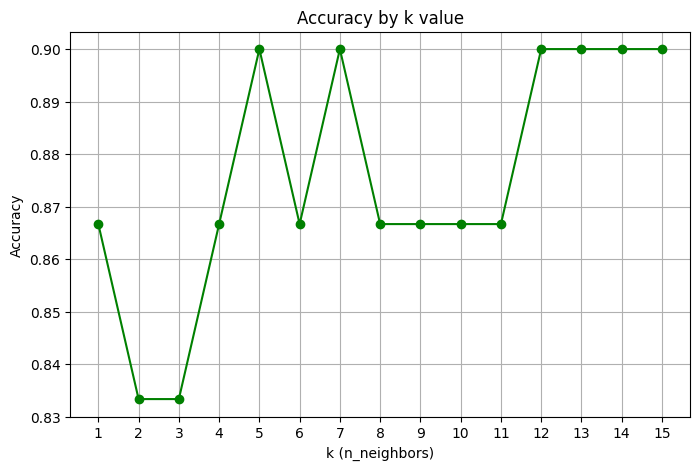

최고 정확도: 0.9
최적의 K: 5


In [25]:
# 1. 시도해볼 K의 최대 범위를 설정
max_k = 15
acc_array = np.zeros(max_k) # max_k개의 0이 들어있는 배열 생성

for i in np.arange(1, max_k + 1, 1):
    # n_neighbors에 현재 숫자(i)를 넣음
    classifier = KNeighborsClassifier(n_neighbors=i).fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)

    # 배열의 인덱스는 0부터 시작하므로 i-1 위치에 저장
    acc_array[i-1] = acc

# 그래프
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, max_k + 1), acc_array, marker='o', color='green')
plt.title('Accuracy by k value')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, max_k + 1)) # x축 눈금을 1~10까지 표시
plt.grid(True)
plt.show()

# 4. 최적의 K 출력
print(f"최고 정확도: {np.max(acc_array)}")
print(f"최적의 K: {np.argmax(acc_array) + 1}")